In [37]:
import kagglehub
import os
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("unsdsn/world-happiness")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\unsdsn\world-happiness\versions\2


In [39]:
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_files[0])
df.shape

(158, 12)

In [40]:
df.head(5)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [41]:
df.tail(5)  

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 19.5 KB


In [43]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.isnull().sum()   

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [46]:
df['Total score'] = (
    df['Happiness Rank'] 
    + df['Happiness Score'] 
    + df['Economy (GDP per Capita)'] 
    + df['Family'] 
    + df['Health (Life Expectancy)'] 
    + df['Freedom'] 
    + df['Trust (Government Corruption)'] 
    + df['Generosity'] 
    + df['Dystopia Residual']
).round(2)


In [47]:
df['Total score'].mean()

np.float64(90.24512658227847)

In [48]:
df['Total score'].describe()    

count    158.000000
mean      90.245127
std       43.483138
min       16.170000
25%       52.740000
50%       89.965000
75%      127.805000
max      163.680000
Name: Total score, dtype: float64

In [49]:
df['Happiness Score'] = df['Happiness Score'].round(2)
df['Happiness Score'].describe()

count    158.000000
mean       5.376203
std        1.145097
min        2.840000
25%        4.527500
50%        5.230000
75%        6.245000
max        7.590000
Name: Happiness Score, dtype: float64

In [54]:
df = df.round(2)

In [53]:
df['Standard Error'] = df['Standard Error'].round(3)

In [56]:
df['Country'].value_counts()

Country
Switzerland    1
Iceland        1
Denmark        1
Norway         1
Canada         1
              ..
Rwanda         1
Benin          1
Syria          1
Burundi        1
Togo           1
Name: count, Length: 158, dtype: int64

In [57]:
df['Region'].value_counts() 

Region
Sub-Saharan Africa                 40
Central and Eastern Europe         29
Latin America and Caribbean        22
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64

In [61]:
tophappy_region = df.groupby('Region')['Happiness Score'].mean().nlargest(10)
index = tophappy_region.index
print(index)

Index(['Australia and New Zealand', 'North America', 'Western Europe',
       'Latin America and Caribbean', 'Eastern Asia',
       'Middle East and Northern Africa', 'Central and Eastern Europe',
       'Southeastern Asia', 'Southern Asia', 'Sub-Saharan Africa'],
      dtype='str', name='Region')


In [63]:
top_happiness_scores = df['Happiness Score'].value_counts().nlargest(10)
top_happiness_scores

Happiness Score
6.30    3
5.19    3
4.51    3
7.28    2
6.94    2
6.48    2
6.00    2
5.98    2
5.89    2
5.83    2
Name: count, dtype: int64

In [68]:

top_10_countries = df['Country'].value_counts().nlargest(10)
print(top_10_countries)

Country
Switzerland    1
Iceland        1
Denmark        1
Norway         1
Canada         1
Finland        1
Netherlands    1
Sweden         1
New Zealand    1
Australia      1
Name: count, dtype: int64


In [70]:
toptrust_region = df.groupby('Region')['Trust (Government Corruption)'].mean().nlargest(10)
print(toptrust_region)

Region
Australia and New Zealand          0.395000
North America                      0.245000
Western Europe                     0.231905
Middle East and Northern Africa    0.183000
Southeastern Asia                  0.150000
Eastern Asia                       0.128333
Sub-Saharan Africa                 0.124000
Latin America and Caribbean        0.116818
Southern Asia                      0.101429
Central and Eastern Europe         0.086207
Name: Trust (Government Corruption), dtype: float64


In [72]:
toptotalscore_region = df.groupby('Region')['Total score'].mean().nlargest(10)
print(toptotalscore_region)

Region
Sub-Saharan Africa                 136.304750
Southern Asia                      122.305714
Southeastern Asia                   91.857778
Central and Eastern Europe          89.666552
Middle East and Northern Africa     88.413500
Eastern Asia                        75.753333
Latin America and Caribbean         59.199545
Western Europe                      42.901905
North America                       24.545000
Australia and New Zealand           24.070000
Name: Total score, dtype: float64


In [73]:
leasttotalscore_region = df.groupby('Region')['Total score'].mean().nsmallest(10)
print(leasttotalscore_region)

Region
Australia and New Zealand           24.070000
North America                       24.545000
Western Europe                      42.901905
Latin America and Caribbean         59.199545
Eastern Asia                        75.753333
Middle East and Northern Africa     88.413500
Central and Eastern Europe          89.666552
Southeastern Asia                   91.857778
Southern Asia                      122.305714
Sub-Saharan Africa                 136.304750
Name: Total score, dtype: float64


In [75]:
toptotalscore_country = df.groupby('Country')['Total score'].mean().nlargest(10)
print(toptotalscore_country)

Country
Togo            163.68
Burundi         162.81
Syria           162.01
Benin           161.68
Rwanda          160.93
Afghanistan     160.15
Burkina Faso    159.17
Ivory Coast     158.31
Guinea          157.31
Chad            156.33
Name: Total score, dtype: float64


In [76]:
top10freedom_region = df.groupby('Region')['Freedom'].mean().nlargest(10)
print(top10freedom_region)

Region
Australia and New Zealand          0.645000
North America                      0.590000
Southeastern Asia                  0.557778
Western Europe                     0.550000
Latin America and Caribbean        0.500455
Eastern Asia                       0.465000
Southern Asia                      0.372857
Sub-Saharan Africa                 0.365750
Middle East and Northern Africa    0.361500
Central and Eastern Europe         0.358621
Name: Freedom, dtype: float64


In [78]:
df.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual', 'Total score'],
      dtype='str')

C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\2492122979.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\2492122979.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


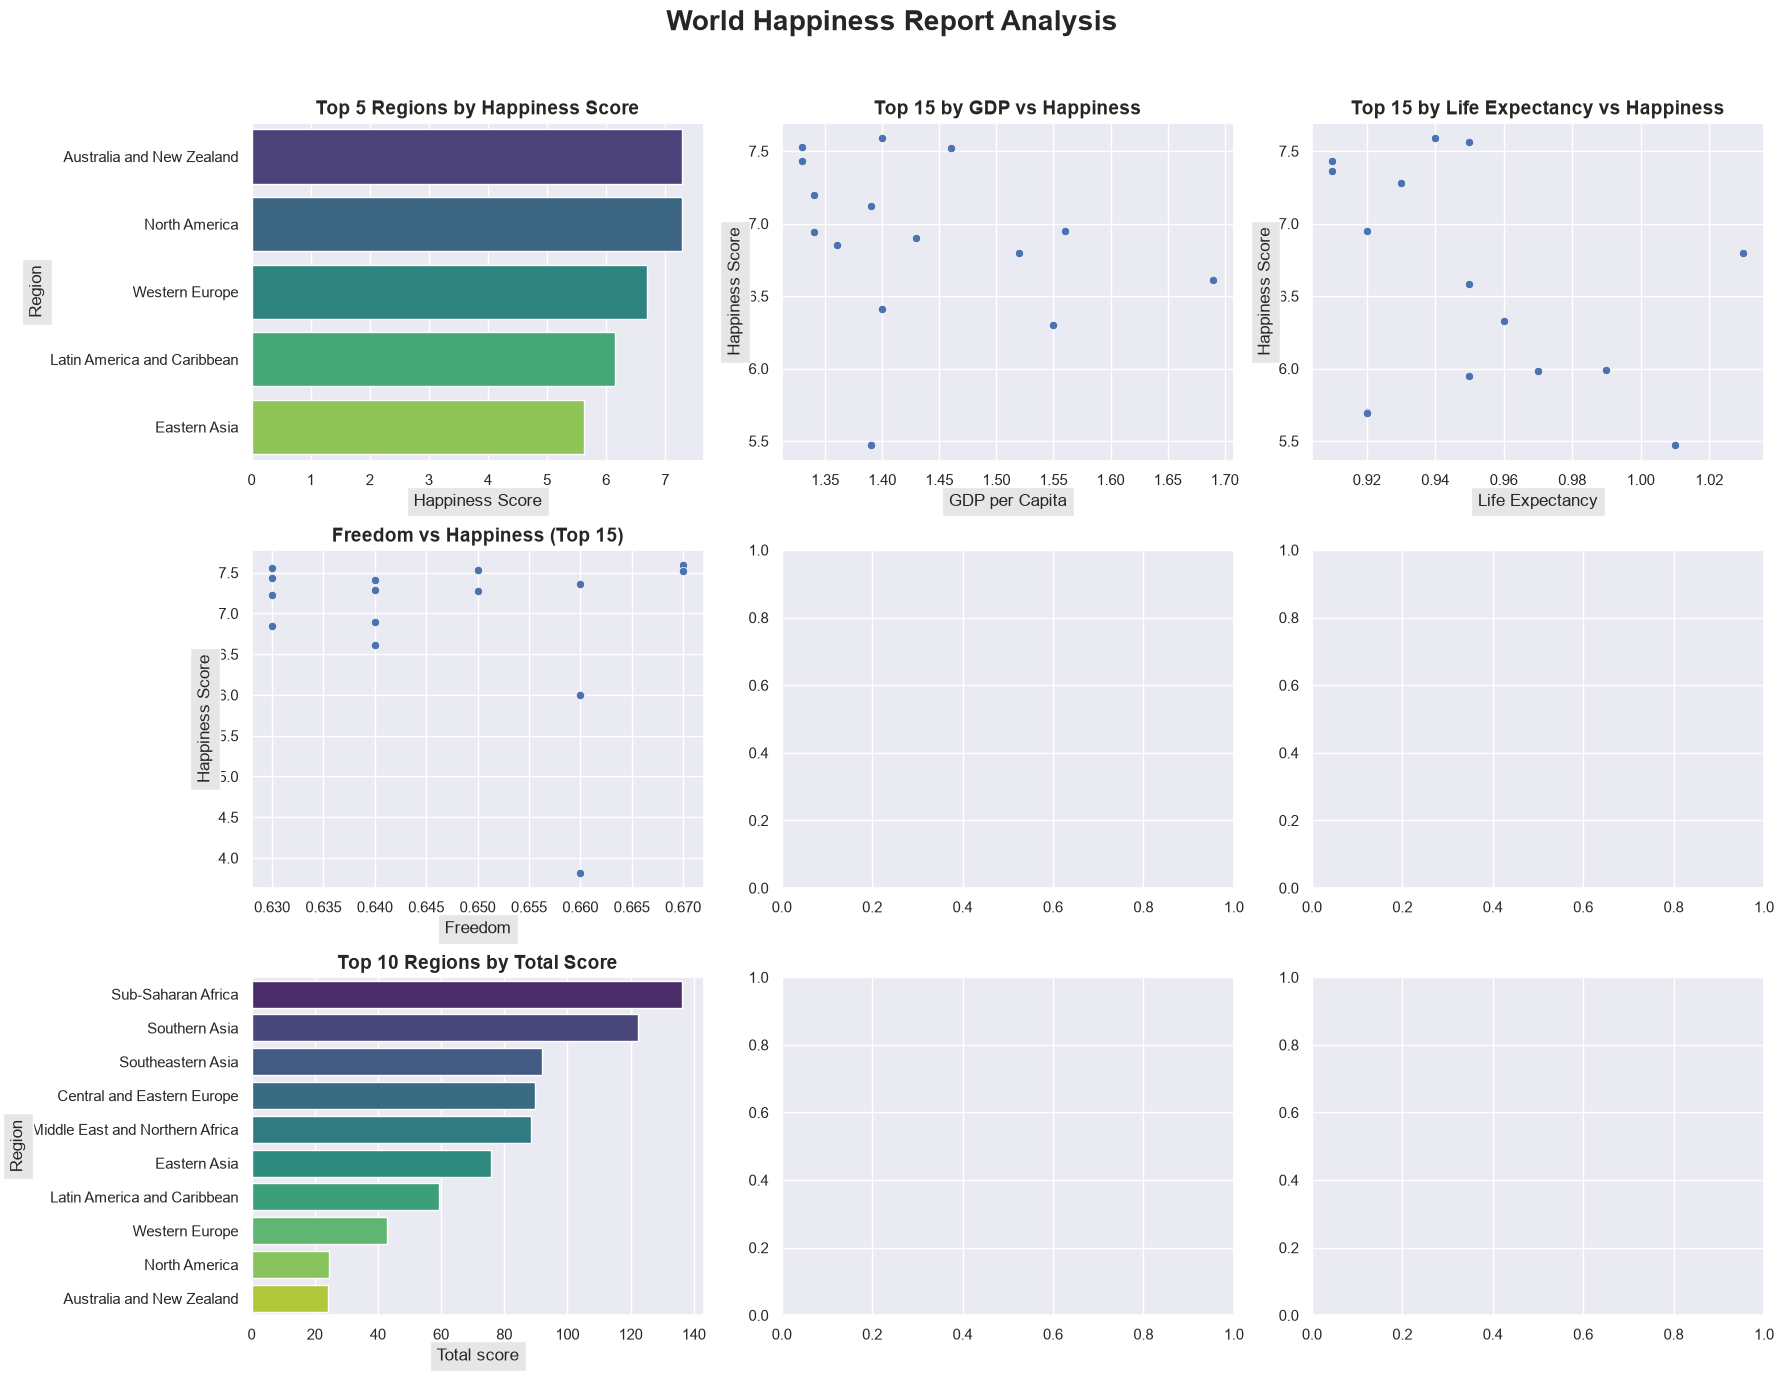

In [109]:
sns.set_style('whitegrid')
sns.set(rc={'figure.figsize': (16, 12)})

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('World Happiness Report Analysis', fontsize=20, fontweight='bold')

ax1 = axes[0, 0]
sns.barplot(
    y=tophappy_region.index[:5],
    x=tophappy_region.values[:5],
    ax=ax1,
    palette="viridis"
)
ax1.set_title("Top 5 Regions by Happiness Score", fontsize=14, fontweight="bold")
ax1.set_xlabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})
ax1.set_ylabel("Region", bbox={'facecolor': '0.9', 'pad': 5})

ax2 = axes[0, 1]
top_gdp = df.nlargest(15, 'Economy (GDP per Capita)')
sns.scatterplot(
    x=top_gdp['Economy (GDP per Capita)'],
    y=top_gdp['Happiness Score'],
    ax=ax2
)
ax2.set_title("Top 15 by GDP vs Happiness", fontsize=14, fontweight="bold")
ax2.set_xlabel("GDP per Capita", bbox={'facecolor': '0.9', 'pad': 5})
ax2.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax3 = axes[0, 2]
top_health = df.nlargest(15, 'Health (Life Expectancy)')
sns.scatterplot(
    x=top_health['Health (Life Expectancy)'],
    y=top_health['Happiness Score'],
    ax=ax3
)
ax3.set_title("Top 15 by Life Expectancy vs Happiness", fontsize=14, fontweight="bold")
ax3.set_xlabel("Life Expectancy", bbox={'facecolor': '0.9', 'pad': 5})
ax3.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax4 = axes[1, 0]
top_freedom = df.nlargest(15, 'Freedom')
sns.scatterplot(
    x=top_freedom['Freedom'],
    y=top_freedom['Happiness Score'],
    ax=ax4
)
ax4.set_title("Freedom vs Happiness (Top 15)", fontsize=14, fontweight="bold")
ax4.set_xlabel("Freedom", bbox={'facecolor': '0.9', 'pad': 5})
ax4.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax5 = axes[2, 0]
sns.barplot(
    x=toptotalscore_region.values[:10],
    y=toptotalscore_region.index[:10],
    ax=ax5,
    palette="viridis"
)
ax5.set_title("Top 10 Regions by Total Score", fontsize=14, fontweight="bold")
ax5.set_xlabel("Total score", bbox={'facecolor': '0.9', 'pad': 5})
ax5.set_ylabel("Region", bbox={'facecolor': '0.9', 'pad': 5})

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\1389921744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\1389921744.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


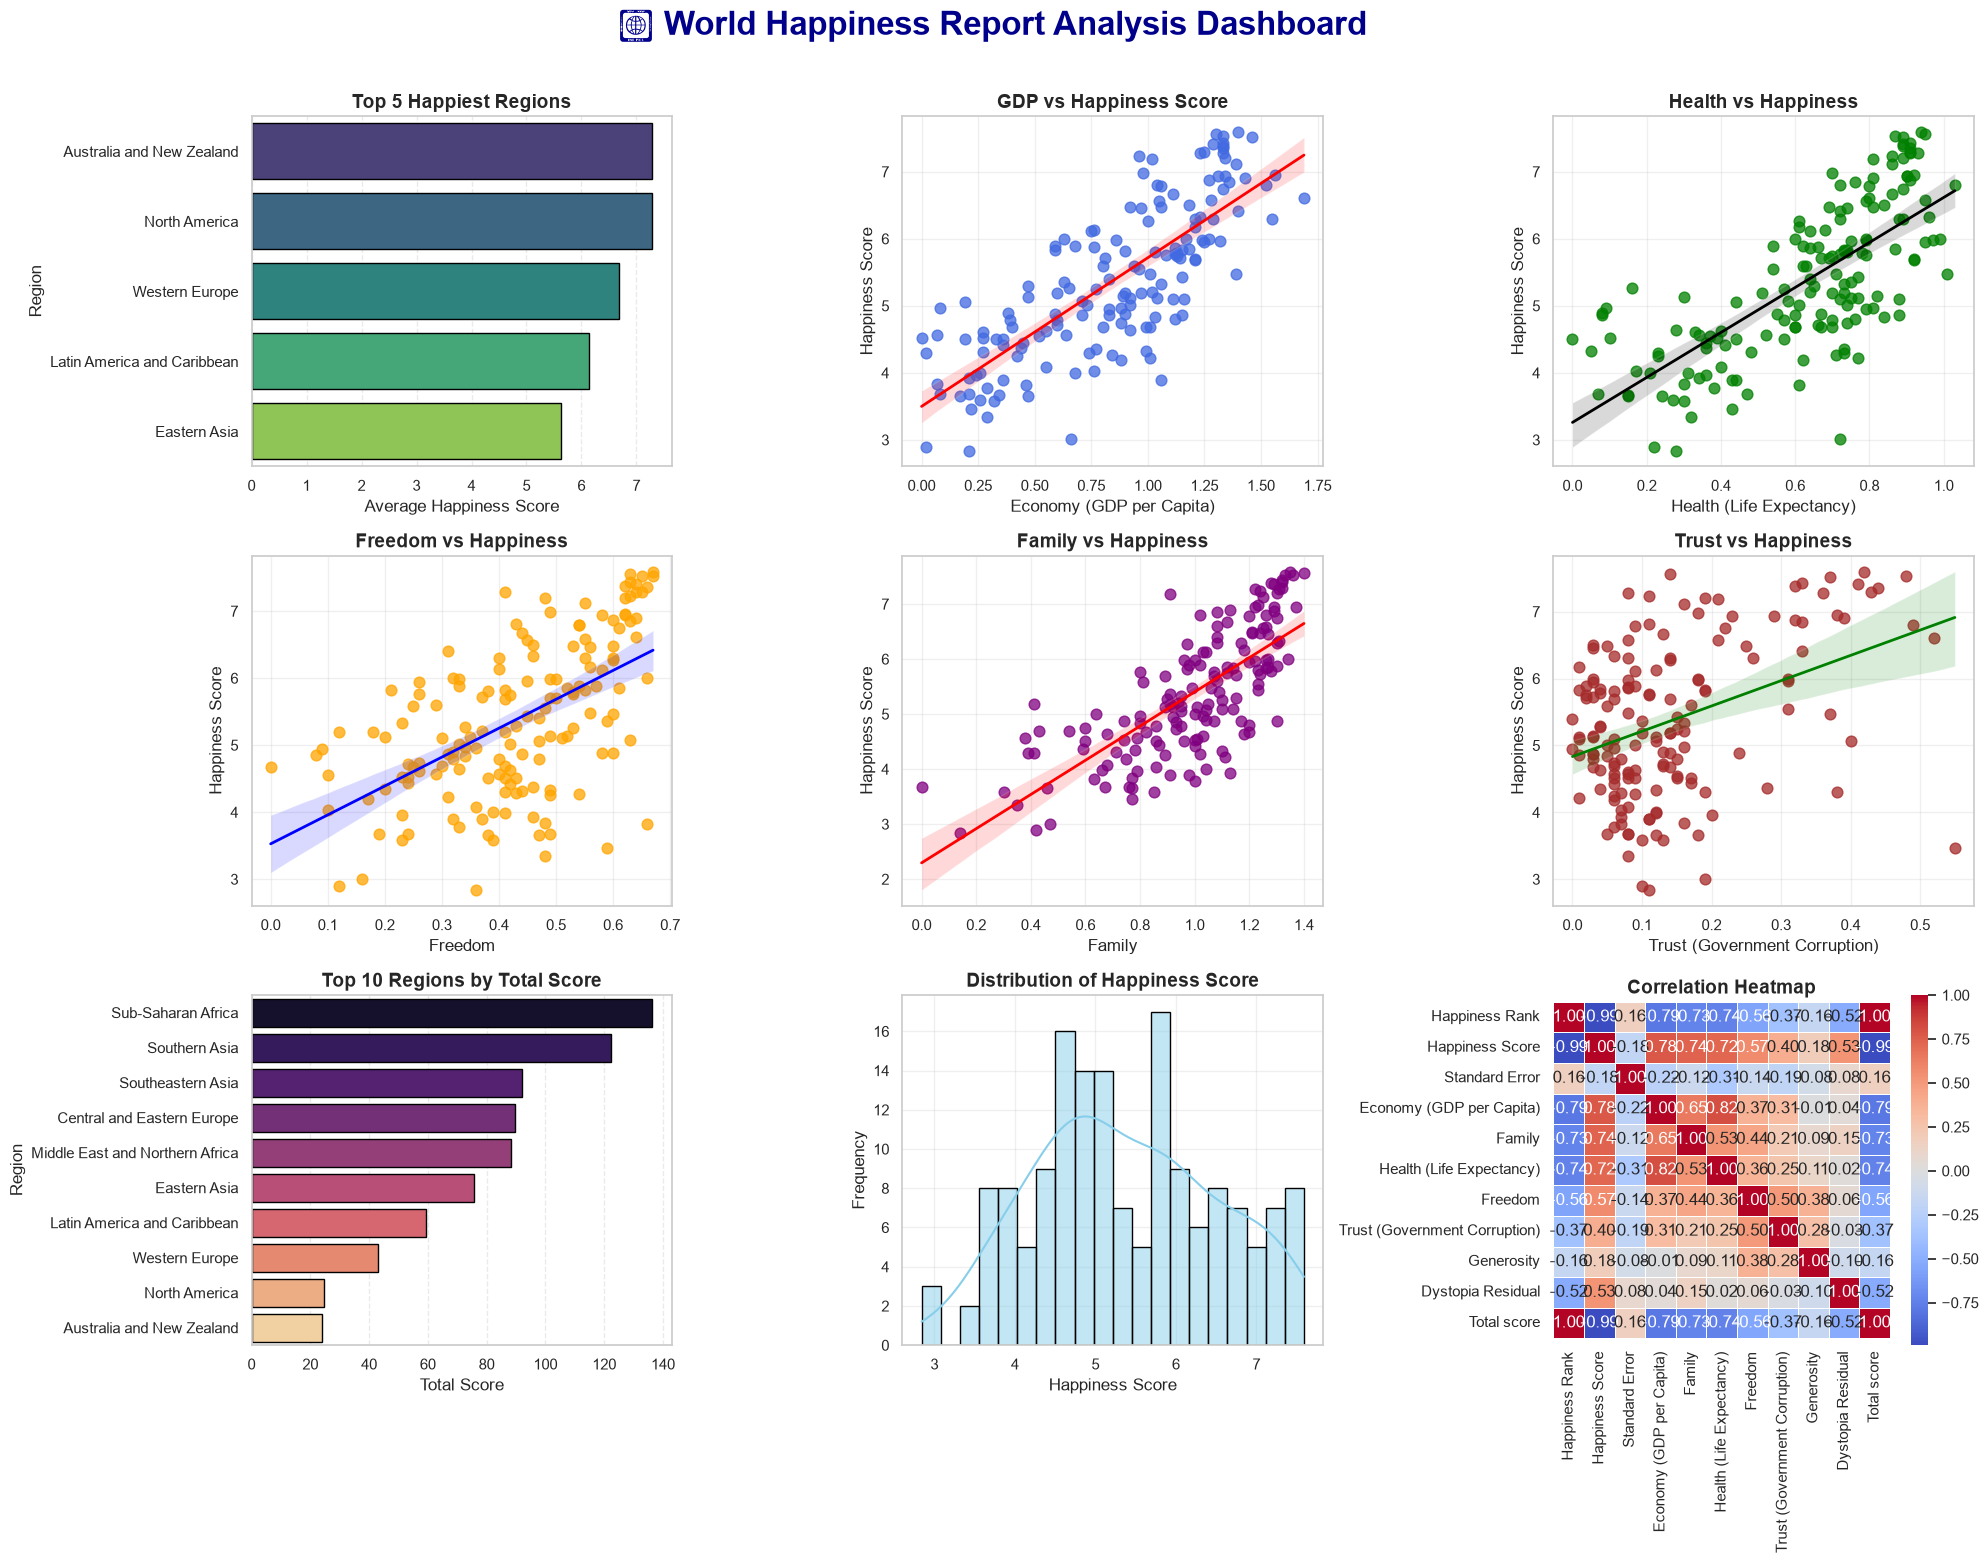

In [110]:


sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle(
    "🌍 World Happiness Report Analysis Dashboard",
    fontsize=24,
    fontweight="bold",
    color="darkblue"
)

ax1 = axes[0, 0]
sns.barplot(
    x=tophappy_region.values[:5],
    y=tophappy_region.index[:5],
    palette="viridis",
    edgecolor="black",
    ax=ax1
)
ax1.set_title("Top 5 Happiest Regions", fontsize=14, fontweight="bold")
ax1.set_xlabel("Average Happiness Score")
ax1.set_ylabel("Region")
ax1.grid(axis="x", linestyle="--", alpha=0.4)

ax2 = axes[0, 1]
sns.regplot(
    data=df,
    x="Economy (GDP per Capita)",
    y="Happiness Score",
    scatter_kws={"s":60, "alpha":0.75, "color":"royalblue"},
    line_kws={"color":"red", "linewidth":2},
    ax=ax2
)
ax2.set_title("GDP vs Happiness Score", fontsize=14, fontweight="bold")
ax2.grid(alpha=0.3)

ax3 = axes[0, 2]
sns.regplot(
    data=df,
    x="Health (Life Expectancy)",
    y="Happiness Score",
    scatter_kws={"s":60, "alpha":0.75, "color":"green"},
    line_kws={"color":"black", "linewidth":2},
    ax=ax3
)
ax3.set_title("Health vs Happiness", fontsize=14, fontweight="bold")
ax3.grid(alpha=0.3)

ax4 = axes[1, 0]
sns.regplot(
    data=df,
    x="Freedom",
    y="Happiness Score",
    scatter_kws={"s":60, "alpha":0.75, "color":"orange"},
    line_kws={"color":"blue", "linewidth":2},
    ax=ax4
)
ax4.set_title("Freedom vs Happiness", fontsize=14, fontweight="bold")
ax4.grid(alpha=0.3)

ax5 = axes[1, 1]
sns.regplot(
    data=df,
    x="Family",
    y="Happiness Score",
    scatter_kws={"s":60, "alpha":0.75, "color":"purple"},
    line_kws={"color":"red", "linewidth":2},
    ax=ax5
)
ax5.set_title("Family vs Happiness", fontsize=14, fontweight="bold")
ax5.grid(alpha=0.3)

ax6 = axes[1, 2]
sns.regplot(
    data=df,
    x="Trust (Government Corruption)",
    y="Happiness Score",
    scatter_kws={"s":60, "alpha":0.75, "color":"brown"},
    line_kws={"color":"green", "linewidth":2},
    ax=ax6
)
ax6.set_title("Trust vs Happiness", fontsize=14, fontweight="bold")
ax6.grid(alpha=0.3)

ax7 = axes[2, 0]
sns.barplot(
    x=toptotalscore_region.values[:10],
    y=toptotalscore_region.index[:10],
    palette="magma",
    edgecolor="black",
    ax=ax7
)
ax7.set_title("Top 10 Regions by Total Score", fontsize=14, fontweight="bold")
ax7.set_xlabel("Total Score")
ax7.set_ylabel("Region")
ax7.grid(axis="x", linestyle="--", alpha=0.4)

ax8 = axes[2, 1]
sns.histplot(
    df["Happiness Score"],
    bins=20,
    kde=True,
    color="skyblue",
    edgecolor="black",
    ax=ax8
)
ax8.set_title("Distribution of Happiness Score", fontsize=14, fontweight="bold")
ax8.set_xlabel("Happiness Score")
ax8.set_ylabel("Frequency")
ax8.grid(alpha=0.3)

ax9 = axes[2, 2]
corr = df.select_dtypes(include="number").corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True,
    ax=ax9
)
ax9.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\1433966592.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\1433966592.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_59836\1433966592.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

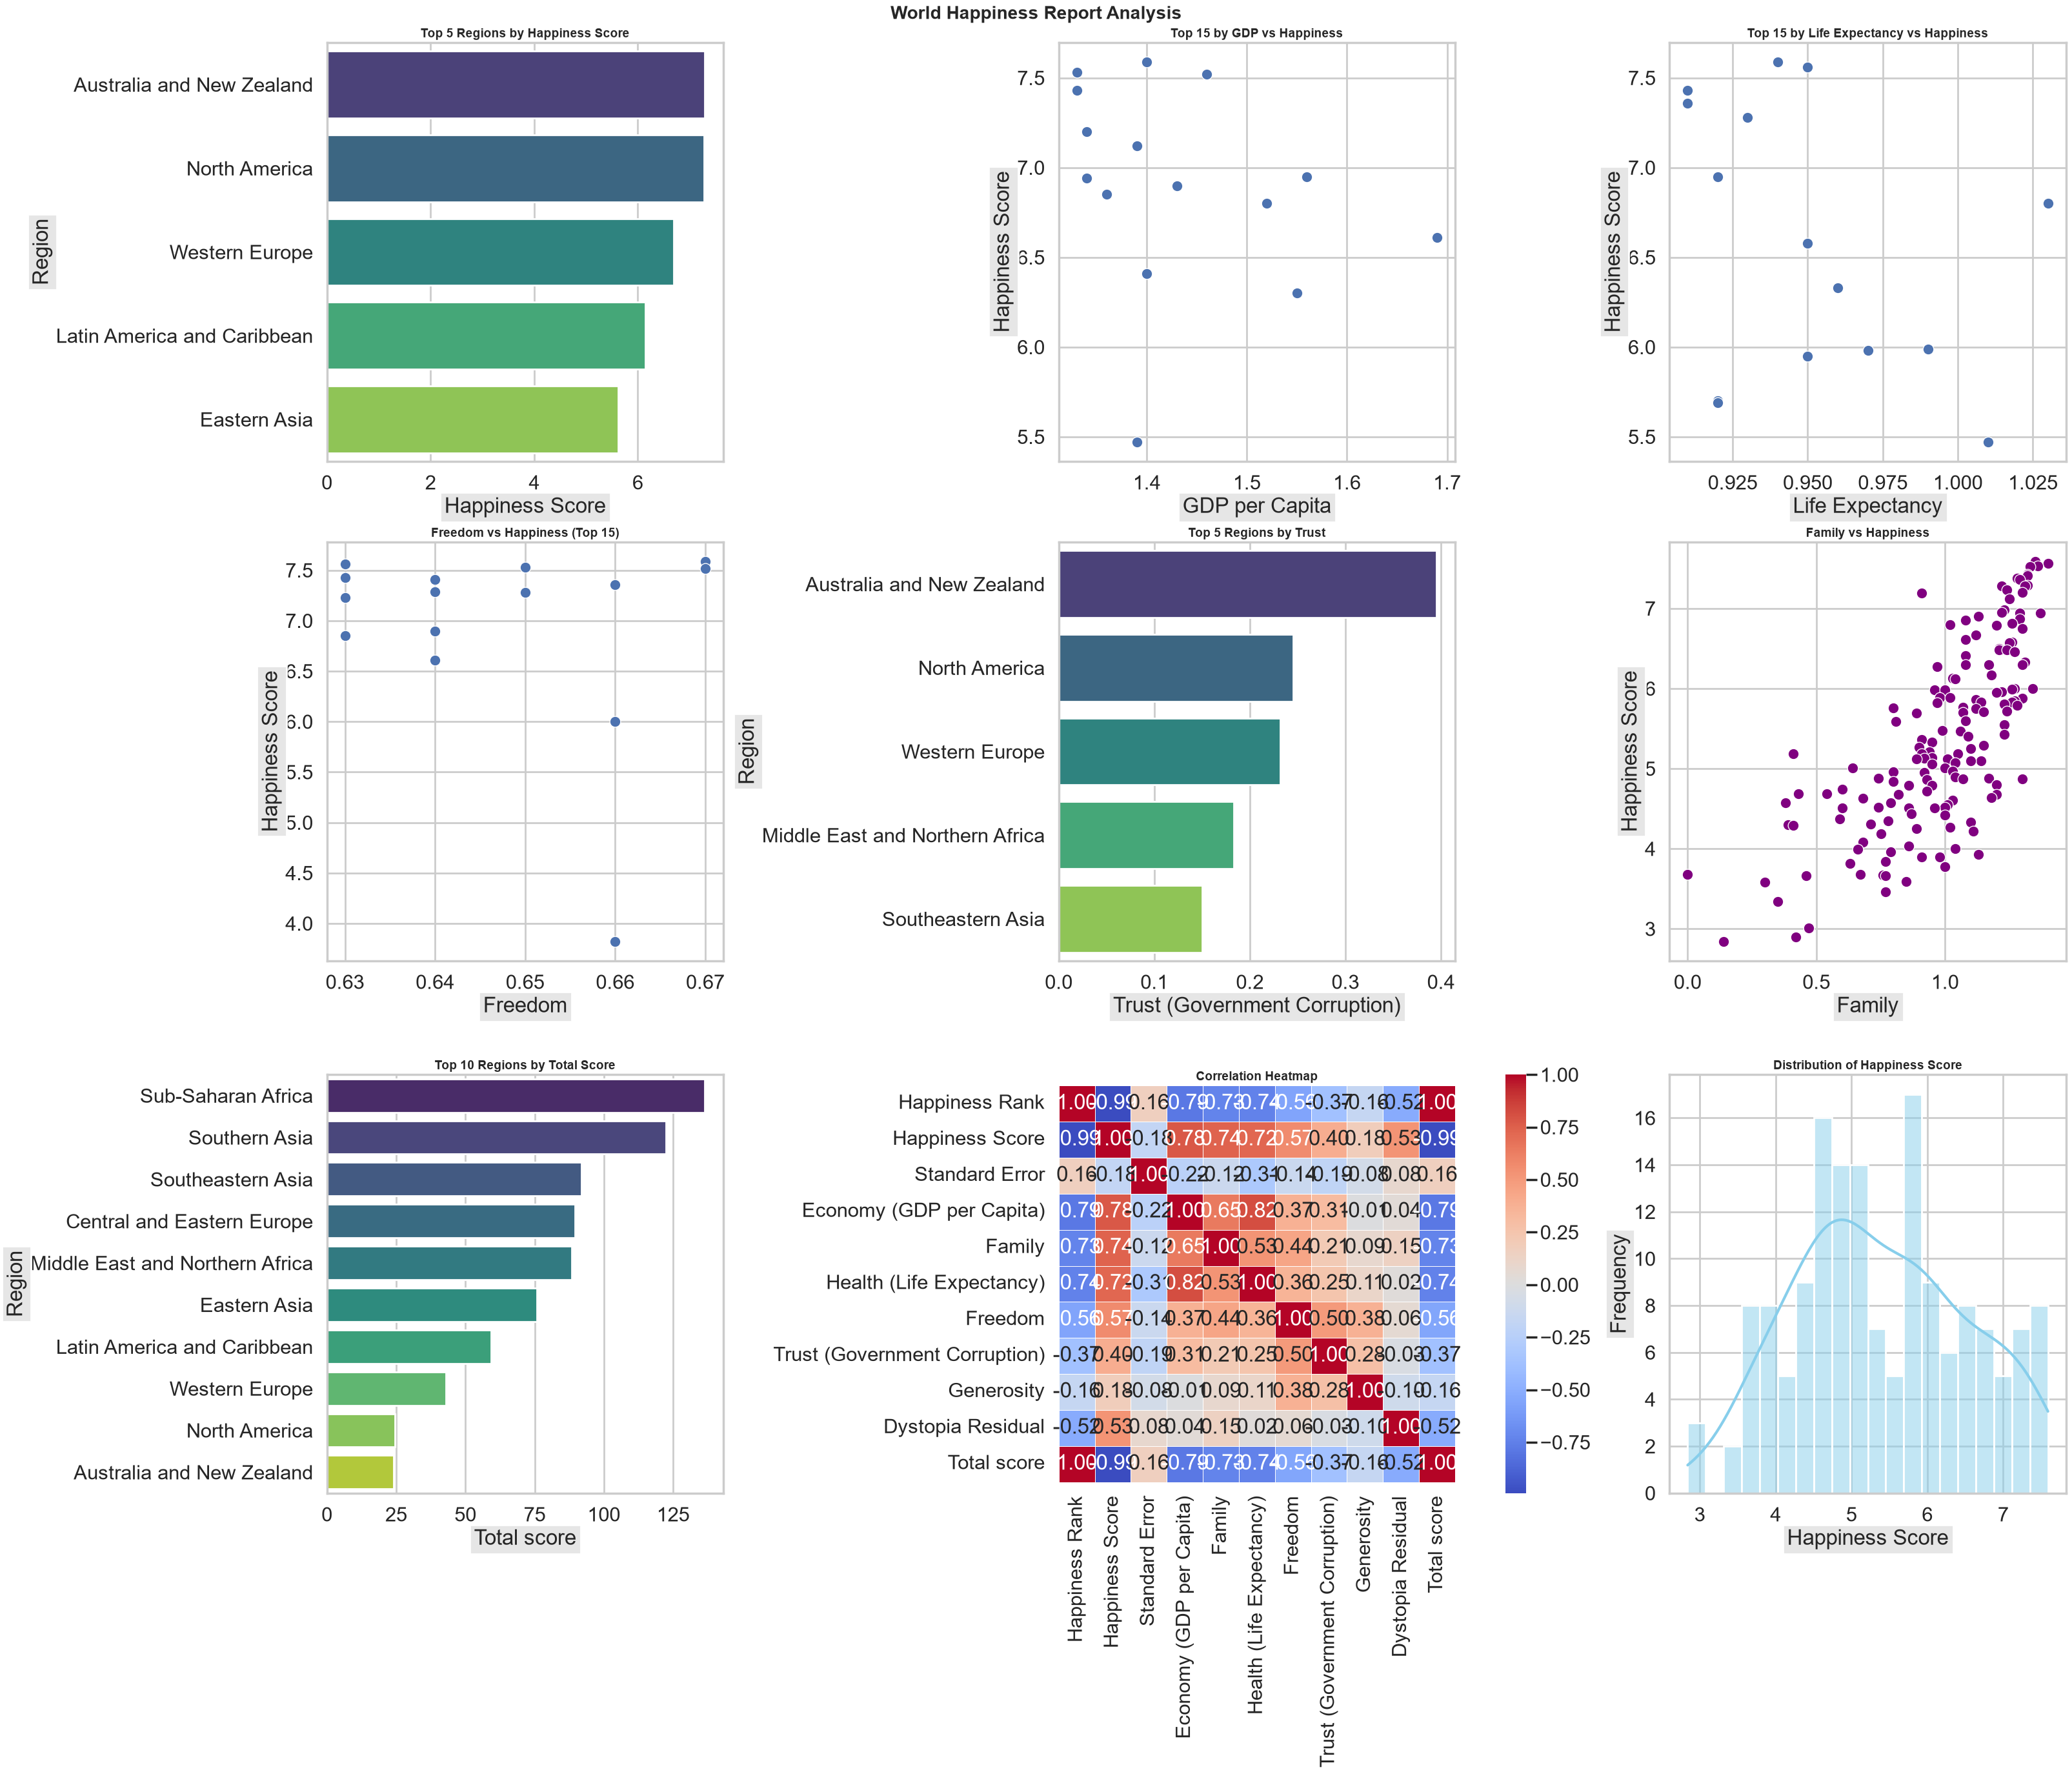

In [115]:
sns.set_style("whitegrid")
sns.set_context("poster")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(32, 24),
    constrained_layout=True
)
fig.suptitle('World Happiness Report Analysis', fontsize=20, fontweight='bold')

ax1 = axes[0, 0]
sns.barplot(
    y=tophappy_region.index[:5],
    x=tophappy_region.values[:5],
    ax=ax1,
    palette="viridis"
)
ax1.set_title("Top 5 Regions by Happiness Score", fontsize=14, fontweight="bold")
ax1.set_xlabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})
ax1.set_ylabel("Region", bbox={'facecolor': '0.9', 'pad': 5})

ax2 = axes[0, 1]
top_gdp = df.nlargest(15, 'Economy (GDP per Capita)')
sns.scatterplot(
    x=top_gdp['Economy (GDP per Capita)'],
    y=top_gdp['Happiness Score'],
    ax=ax2
)
ax2.set_title("Top 15 by GDP vs Happiness", fontsize=14, fontweight="bold")
ax2.set_xlabel("GDP per Capita", bbox={'facecolor': '0.9', 'pad': 5})
ax2.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax3 = axes[0, 2]
top_health = df.nlargest(15, 'Health (Life Expectancy)')
sns.scatterplot(
    x=top_health['Health (Life Expectancy)'],
    y=top_health['Happiness Score'],
    ax=ax3
)
ax3.set_title("Top 15 by Life Expectancy vs Happiness", fontsize=14, fontweight="bold")
ax3.set_xlabel("Life Expectancy", bbox={'facecolor': '0.9', 'pad': 5})
ax3.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax4 = axes[1, 0]
top_freedom = df.nlargest(15, 'Freedom')
sns.scatterplot(
    x=top_freedom['Freedom'],
    y=top_freedom['Happiness Score'],
    ax=ax4
)
ax4.set_title("Freedom vs Happiness (Top 15)", fontsize=14, fontweight="bold")
ax4.set_xlabel("Freedom", bbox={'facecolor': '0.9', 'pad': 5})
ax4.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax5 = axes[2, 0]
sns.barplot(
    x=toptotalscore_region.values[:10],
    y=toptotalscore_region.index[:10],
    ax=ax5,
    palette="viridis"
)
ax5.set_title("Top 10 Regions by Total Score", fontsize=14, fontweight="bold")
ax5.set_xlabel("Total score", bbox={'facecolor': '0.9', 'pad': 5})
ax5.set_ylabel("Region", bbox={'facecolor': '0.9', 'pad': 5})

ax6 = axes[1, 1]
sns.barplot(
    y=toptrust_region.index[:5],
    x=toptrust_region.values[:5],
    ax=ax6,
    palette="viridis"
)
ax6.set_title("Top 5 Regions by Trust", fontsize=14, fontweight="bold")
ax6.set_xlabel("Trust (Government Corruption)", bbox={'facecolor': '0.9', 'pad': 5})
ax6.set_ylabel("Region", bbox={'facecolor': '0.9', 'pad': 5})

ax7 = axes[1, 2]
sns.scatterplot(
    x=df['Family'],
    y=df['Happiness Score'],
    ax=ax7,
    color='purple'
)
ax7.set_title("Family vs Happiness", fontsize=14, fontweight="bold")
ax7.set_xlabel("Family", bbox={'facecolor': '0.9', 'pad': 5})
ax7.set_ylabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})

ax8 = axes[2, 2]
sns.histplot(
    df['Happiness Score'],
    bins=20,
    kde=True,
    color='skyblue',
    ax=ax8
)
ax8.set_title("Distribution of Happiness Score", fontsize=14, fontweight="bold")
ax8.set_xlabel("Happiness Score", bbox={'facecolor': '0.9', 'pad': 5})
ax8.set_ylabel("Frequency", bbox={'facecolor': '0.9', 'pad': 5})

ax9 = axes[2, 1]
corr = df.select_dtypes(include='number').corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True,
    ax=ax9
)
ax9.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [116]:
clean_data_path = "world_happiness_clean.csv"
df.to_csv(clean_data_path, index=False)

print(f"Clean dataset exported to: {clean_data_path}")

Clean dataset exported to: world_happiness_clean.csv
